## 1. Imports

In [1]:
import warnings, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from collections import defaultdict
import re
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
import torchvision.models as tv_models
from sklearn.metrics import (accuracy_score, classification_report,
                              roc_auc_score, roc_curve, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.model_selection import StratifiedKFold

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
OUTPUT_DIR  = Path("outputs_image_fixed")
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"Device : {DEVICE}")

Device : cuda


## 2. Configuration

In [5]:
import zipfile

with zipfile.ZipFile("/content/Fetal Brain Abnormalities Ultrasound.zip", "r") as z:
    print(f"Files in zip: {len(z.namelist())}")
    print("First 3:", z.namelist()[:3])
    z.extractall("/content/")
    print("Extracted ✅")

Files in zip: 3554
First 3: ['Fetal Brain Abnormalities Ultrasound/', '__MACOSX/._Fetal Brain Abnormalities Ultrasound', 'Fetal Brain Abnormalities Ultrasound/README.roboflow.txt']
Extracted ✅


In [14]:
# ── EDIT THIS ──────────────────────────────────────────────────────────────────
DATA_ROOT = Path("/content/Fetal Brain Abnormalities Ultrasound")
# Colab: Path("/content/Fetal Brain Abnormalities Ultrasound")
# ──────────────────────────────────────────────────────────────────────────────

IMG_SIZE    = 224    # standard for pretrained models
BATCH_SIZE  = 32
MAX_EPOCHS  = 10     # early stopping will stop before this
LR          = 5e-5
PATIENCE    = 3      # early stopping patience
N_FOLDS     = 5
EMBED_DIM   = 128
DROPOUT     = 0.4
RANDOM_SEED = 42

TRAIN_DIR = DATA_ROOT / "train"
VALID_DIR = DATA_ROOT / "valid"
TEST_DIR  = DATA_ROOT / "test"

print(f"Train exists: {TRAIN_DIR.exists()}")
print(f"Valid exists: {VALID_DIR.exists()}")
print(f"Test  exists: {TEST_DIR.exists()}")

Train exists: True
Valid exists: True
Test  exists: True


## 3. Leak-Free Dataset Loading
> **Fix 1:** Group augmented versions by base image name.
> Split by base image so no original image appears in both train and test.


In [15]:
def get_base_name(filename: str) -> str:
    """
    Extract base image name by removing augmentation suffix.
    'Copy-of-anold-chiari-001_aug_3_jpg.rf.abc123.jpg' -> 'copy-of-anold-chiari-001'
    'Patient00710_Plane3_1_jpg.rf.abc123.jpg'          -> 'patient00710_plane3'
    """
    fname = filename.lower()
    # Remove extension and hash
    fname = re.sub(r'\.jpg.*$', '', fname)
    fname = re.sub(r'\.rf\.[a-z0-9]+$', '', fname)
    # Remove augmentation suffix
    fname = re.sub(r'_aug_\d+.*$', '', fname)
    fname = re.sub(r'_jpg.*$', '', fname)
    # Remove trailing numbers
    fname = re.sub(r'_\d+$', '', fname)
    return fname.strip('_-')

def assign_label(filename: str) -> int:
    return 0 if filename.lower().startswith("patient00") else 1

def build_full_manifest(split_dirs: list) -> pd.DataFrame:
    """Load all images from multiple split dirs into one manifest."""
    rows = []
    for split_dir in split_dirs:
        for p in sorted(list(split_dir.glob("*.jpg")) +
                        list(split_dir.glob("*.JPG"))):
            lbl  = assign_label(p.name)
            base = get_base_name(p.name)
            rows.append({"filepath": str(p), "filename": p.name,
                         "base_name": base, "risk_label": lbl})
    return pd.DataFrame(rows)

# Load ALL images (train+valid+test combined) for leak-free resplit
all_df = build_full_manifest([TRAIN_DIR, VALID_DIR, TEST_DIR])
print(f"Total images: {len(all_df)}")
print(f"Unique base images: {all_df['base_name'].nunique()}")
print(f"Normal={( all_df.risk_label==0).sum()} | Abnormal={(all_df.risk_label==1).sum()}")

# Show example base name extraction
print("\nExample base name extraction:")
for fname in all_df['filename'].head(3):
    print(f"  {fname[:50]:50s} -> {get_base_name(fname)}")

Total images: 1768
Unique base images: 320
Normal=282 | Abnormal=1486

Example base name extraction:
  Copy-of-anold-chiari-malformation-16e_aug_0_png_jp -> copy-of-anold-chiari-malformation-16e
  Copy-of-anold-chiari-malformation-16e_aug_0_png_jp -> copy-of-anold-chiari-malformation-16e
  Copy-of-anold-chiari-malformation-16e_aug_1_png_jp -> copy-of-anold-chiari-malformation-16e


## 4. Leak-Free Train/Test Split by Base Image

In [18]:
from sklearn.model_selection import train_test_split as sk_split

# Get unique base images and their labels
base_df = all_df.groupby("base_name").agg(
    risk_label=("risk_label","first")
).reset_index()

print(f"Unique base images: {len(base_df)}")
print(f"Normal bases  : {(base_df.risk_label==0).sum()}")
print(f"Abnormal bases: {(base_df.risk_label==1).sum()}")

# Split base images into train (80%) and test (20%)
# All augmented versions of a base image go to the SAME split
train_bases, test_bases = sk_split(
    base_df["base_name"],
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=base_df["risk_label"]
)
train_bases = set(train_bases)
test_bases  = set(test_bases)

train_df = all_df[all_df["base_name"].isin(train_bases)].reset_index(drop=True)
test_df  = all_df[all_df["base_name"].isin(test_bases)].reset_index(drop=True)

print(f"\nLeak-free split:")
print(f"  Train: {len(train_df)} images | "
      f"Normal={( train_df.risk_label==0).sum()} | "
      f"Abnormal={(train_df.risk_label==1).sum()}")
print(f"  Test : {len(test_df)}  images | "
      f"Normal={( test_df.risk_label==0).sum()} | "
      f"Abnormal={(test_df.risk_label==1).sum()}")

# Verify NO base image appears in both splits
overlap = train_bases.intersection(test_bases)
print(f"\n✅ Base image overlap between train and test: {len(overlap)} (must be 0)")

Unique base images: 320
Normal bases  : 107
Abnormal bases: 213

Leak-free split:
  Train: 1411 images | Normal=218 | Abnormal=1193
  Test : 357  images | Normal=64 | Abnormal=293

✅ Base image overlap between train and test: 0 (must be 0)


## 5. Augmentation-Based Balancing
> **Fix 2:** Instead of duplicating images (oversampling),
> apply HEAVY augmentation to minority class at load time.
> Every epoch sees genuinely different versions — no memorization.


In [19]:
# Pixel stats from training data only
sample_paths = train_df.sample(min(300, len(train_df)),
               random_state=RANDOM_SEED)["filepath"].tolist()
means = [np.array(Image.open(p).convert("RGB").resize((IMG_SIZE,IMG_SIZE)),
         dtype=np.float32).mean(axis=(0,1))/255. for p in sample_paths]
MEAN = np.array(means).mean(axis=0).tolist()
STD  = [0.229, 0.224, 0.225]  # ImageNet std — good for pretrained models
print(f"Channel means: {[round(v,4) for v in MEAN]}")

# Standard transform for Abnormal (majority) and test/val
standard_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

# HEAVY augmentation for Normal (minority) — genuinely different each epoch
heavy_tf = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomCrop((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(degrees=25),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

print("Transforms defined:")
print("  Standard (Abnormal + test): basic resize + normalize")
print("  Heavy    (Normal minority): 8 augmentation ops — unique each epoch")

Channel means: [0.239, 0.2391, 0.239]
Transforms defined:
  Standard (Abnormal + test): basic resize + normalize
  Heavy    (Normal minority): 8 augmentation ops — unique each epoch


## 6. PyTorch Dataset with Per-Class Transforms

In [20]:
class FetalBrainDataset(Dataset):
    """
    Applies heavy augmentation to minority class (Normal=0)
    and standard transform to majority class (Abnormal=1).
    This balances the effective training distribution without duplication.
    """
    def __init__(self, df, is_train=True):
        self.df       = df.reset_index(drop=True)
        self.is_train = is_train

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row.filepath).convert("RGB")
        label = int(row.risk_label)
        if self.is_train:
            # Apply heavy augmentation to minority Normal class
            tf = heavy_tf if label == 0 else standard_tf
        else:
            tf = standard_tf
        return tf(image), torch.tensor(label, dtype=torch.long)

# Class weights for loss function (still needed even with augmentation)
train_counts  = np.bincount(train_df["risk_label"].values)
CLASS_WEIGHTS = torch.tensor(1.0 / train_counts, dtype=torch.float32).to(DEVICE)
print(f"Train class counts: Normal={train_counts[0]} | Abnormal={train_counts[1]}")
print(f"Class weights     : Normal={CLASS_WEIGHTS[0]:.4f} | Abnormal={CLASS_WEIGHTS[1]:.4f}")

test_ds     = FetalBrainDataset(test_df,  is_train=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"\nTest set: {len(test_ds)} images")

Train class counts: Normal=218 | Abnormal=1193
Class weights     : Normal=0.0046 | Abnormal=0.0008

Test set: 357 images


## 7. ResNet-18 Model with Embedding Output

In [23]:
class ResNet18Branch(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_classes=2, dropout=DROPOUT):
        super().__init__()
        base = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(base.children())[:-1])

        # Freeze backbone — only train the head
        for param in self.backbone.parameters():
            param.requires_grad = False

        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x, return_embedding=False):
        feat  = self.backbone(x)
        embed = self.embedding(feat)
        if return_embedding:
            return embed
        return self.classifier(embed)

# Test model
test_model = ResNet18Branch()
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
print(f"Output shape    : {test_model(dummy).shape}")
print(f"Embedding shape : {test_model(dummy, return_embedding=True).shape}")
trainable = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in test_model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} (backbone frozen)")
del test_model

Output shape    : torch.Size([2, 2])
Embedding shape : torch.Size([2, 128])
Trainable params: 65,922 / 11,242,434 (backbone frozen)


## 8. Training with Early Stopping
> **Fix 3:** Stop training when val loss stops improving.
> Prevents memorization — keeps train acc realistic.


In [24]:
def train_one_fold(train_df_fold, val_df_fold, fold_num):
    train_ds  = FetalBrainDataset(train_df_fold, is_train=True)
    val_ds    = FetalBrainDataset(val_df_fold,   is_train=False)
    train_ld  = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=2)
    val_ld    = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=2)

    model     = ResNet18Branch().to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3,
                                                  factor=0.5)

    best_val_loss = float("inf")
    best_weights  = None
    patience_ctr  = 0
    history       = {"train_loss":[],"train_acc":[],"val_loss":[],"val_acc":[]}

    for epoch in range(1, MAX_EPOCHS + 1):
        # Train
        model.train(); rl,rc,rt = 0.,0,0
        for imgs, labels in train_ld:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out  = model(imgs); loss = criterion(out, labels)
            loss.backward(); optimizer.step()
            rl += loss.item()*imgs.size(0)
            rc += (out.argmax(1)==labels).sum().item()
            rt += labels.size(0)

        # Validate
        model.eval(); vl,vc,vt = 0.,0,0
        with torch.no_grad():
            for imgs, labels in val_ld:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out = model(imgs)
                vl += criterion(out,labels).item()*imgs.size(0)
                vc += (out.argmax(1)==labels).sum().item()
                vt += labels.size(0)

        tl,ta,vla,va = rl/rt,rc/rt,vl/vt,vc/vt
        scheduler.step(vla)
        for k,v in zip(["train_loss","train_acc","val_loss","val_acc"],
                       [tl,ta,vla,va]):
            history[k].append(v)

        # Early stopping
        if vla < best_val_loss - 1e-4:
            best_val_loss = vla
            best_weights  = copy.deepcopy(model.state_dict())
            patience_ctr  = 0
        else:
            patience_ctr += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Fold {fold_num} Ep {epoch:02d} | "
                  f"TLoss:{tl:.4f} TAcc:{ta:.4f} | "
                  f"VLoss:{vla:.4f} VAcc:{va:.4f} | "
                  f"Patience:{patience_ctr}/{PATIENCE}")

        if patience_ctr >= PATIENCE:
            print(f"  Early stopping at epoch {epoch} ✅")
            break

    # Restore best weights
    model.load_state_dict(best_weights)
    return model, history

print("Training function defined with early stopping ✅")

Training function defined with early stopping ✅


## 9. 5-Fold Cross Validation
> **Fix 4:** Report mean ± std across 5 folds.
> Required for IEEE conference papers.


In [25]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

fold_metrics = []
fold_models  = []
fold_histories = []

print(f"Running {N_FOLDS}-Fold Cross Validation...\n")

for fold, (train_idx, val_idx) in enumerate(
        skf.split(train_df, train_df["risk_label"]), 1):

    print(f"{'='*50}")
    print(f"Fold {fold}/{N_FOLDS}")
    print(f"{'='*50}")

    fold_train = train_df.iloc[train_idx].reset_index(drop=True)
    fold_val   = train_df.iloc[val_idx].reset_index(drop=True)

    print(f"  Train: {len(fold_train)} | Val: {len(fold_val)}")

    model, history = train_one_fold(fold_train, fold_val, fold)
    fold_models.append(model)
    fold_histories.append(history)

    # Evaluate on TEST set
    model.eval()
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(DEVICE)
            out  = model(imgs)
            pr   = torch.softmax(out,1)[:,1].cpu().numpy()
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(lbls.numpy())
            probs.extend(pr)

    preds  = np.array(preds)
    labels = np.array(labels)
    probs  = np.array(probs)
    rep    = classification_report(labels, preds,
             target_names=["Low Risk","High Risk"], output_dict=True)

    metrics = {
        "Accuracy":  accuracy_score(labels, preds),
        "Precision": rep["High Risk"]["precision"],
        "Recall":    rep["High Risk"]["recall"],
        "F1-Score":  rep["High Risk"]["f1-score"],
        "ROC-AUC":   roc_auc_score(labels, probs),
    }
    fold_metrics.append(metrics)
    print(f"  Test → Acc:{metrics['Accuracy']:.4f} "
          f"AUC:{metrics['ROC-AUC']:.4f} "
          f"F1:{metrics['F1-Score']:.4f}\n")

Running 5-Fold Cross Validation...

Fold 1/5
  Train: 1128 | Val: 283
  Fold 1 Ep 01 | TLoss:0.6774 TAcc:0.6188 | VLoss:0.6271 VAcc:0.7703 | Patience:0/3
  Fold 1 Ep 05 | TLoss:0.4189 TAcc:0.9087 | VLoss:0.4269 VAcc:0.9081 | Patience:0/3
  Fold 1 Ep 10 | TLoss:0.2555 TAcc:0.9362 | VLoss:0.3047 VAcc:0.9152 | Patience:0/3
  Test → Acc:0.9188 AUC:0.9619 F1:0.9519

Fold 2/5
  Train: 1129 | Val: 282
  Fold 2 Ep 01 | TLoss:0.6516 TAcc:0.5598 | VLoss:0.5461 VAcc:0.8936 | Patience:0/3
  Fold 2 Ep 05 | TLoss:0.3891 TAcc:0.8981 | VLoss:0.3632 VAcc:0.9468 | Patience:0/3
  Fold 2 Ep 10 | TLoss:0.2544 TAcc:0.9309 | VLoss:0.2463 VAcc:0.9504 | Patience:0/3
  Test → Acc:0.9328 AUC:0.9640 F1:0.9600

Fold 3/5
  Train: 1129 | Val: 282
  Fold 3 Ep 01 | TLoss:0.6377 TAcc:0.6988 | VLoss:0.5715 VAcc:0.8652 | Patience:0/3
  Fold 3 Ep 05 | TLoss:0.3910 TAcc:0.9185 | VLoss:0.3880 VAcc:0.9184 | Patience:0/3
  Fold 3 Ep 10 | TLoss:0.2360 TAcc:0.9469 | VLoss:0.2566 VAcc:0.9397 | Patience:0/3
  Test → Acc:0.9244 AU

## 10. Results with Mean ± Std

In [26]:
metrics_df = pd.DataFrame(fold_metrics)

print("=" * 65)
print("   IMAGE BRANCH — 5-FOLD CROSS VALIDATION RESULTS ")
print("=" * 65)
print(f"{'Metric':<15} {'Fold1':>8} {'Fold2':>8} {'Fold3':>8} "
      f"{'Fold4':>8} {'Fold5':>8} {'Mean':>8} {'±Std':>8}")
print("-" * 65)

summary = {}
for col in metrics_df.columns:
    vals = metrics_df[col].values
    mean, std = vals.mean(), vals.std()
    summary[col] = (mean, std)
    row = f"{col:<15}"
    for v in vals: row += f" {v:>8.4f}"
    row += f" {mean:>8.4f} {std:>8.4f}"
    print(row)

print("=" * 65)
print(f"\n✅ Final reported metrics (Mean ± Std):")
for metric, (mean, std) in summary.items():
    print(f"  {metric:<12}: {mean:.4f} ± {std:.4f}")

# Save
metrics_df.to_csv(OUTPUT_DIR/"cv_fold_metrics.csv", index=False)
pd.DataFrame([{k:f"{v[0]:.4f}±{v[1]:.4f}" for k,v in summary.items()}]).to_csv(
    OUTPUT_DIR/"cv_summary.csv", index=False)

   IMAGE BRANCH — 5-FOLD CROSS VALIDATION RESULTS 
Metric             Fold1    Fold2    Fold3    Fold4    Fold5     Mean     ±Std
-----------------------------------------------------------------
Accuracy          0.9188   0.9328   0.9244   0.9160   0.9216   0.9227   0.0058
Precision         0.9258   0.9381   0.9346   0.9311   0.9316   0.9323   0.0041
Recall            0.9795   0.9829   0.9761   0.9693   0.9761   0.9768   0.0045
F1-Score          0.9519   0.9600   0.9549   0.9498   0.9533   0.9540   0.0034
ROC-AUC           0.9619   0.9640   0.9670   0.9611   0.9612   0.9631   0.0022

✅ Final reported metrics (Mean ± Std):
  Accuracy    : 0.9227 ± 0.0058
  Precision   : 0.9323 ± 0.0041
  Recall      : 0.9768 ± 0.0045
  F1-Score    : 0.9540 ± 0.0034
  ROC-AUC     : 0.9631 ± 0.0022


## 11. Best Fold Model — Detailed Evaluation

In [27]:
# Select best fold by accuracy
best_fold_idx = np.argmax([m["Accuracy"] for m in fold_metrics])
best_model    = fold_models[best_fold_idx]
print(f"Best fold: {best_fold_idx+1} "
      f"(Acc={fold_metrics[best_fold_idx]['Accuracy']:.4f})")

# Final evaluation
best_model.eval()
preds, labels, probs = [], [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(DEVICE)
        out  = best_model(imgs)
        pr   = torch.softmax(out,1)[:,1].cpu().numpy()
        preds.extend(out.argmax(1).cpu().numpy())
        labels.extend(lbls.numpy())
        probs.extend(pr)

preds  = np.array(preds)
labels = np.array(labels)
probs  = np.array(probs)

print("\nClassification Report:")
print(classification_report(labels, preds,
      target_names=["Low Risk (Normal)","High Risk (Abnormal)"]))

# Save best model
torch.save(best_model.state_dict(), OUTPUT_DIR/"resnet18_best_fold.pth")
np.save(OUTPUT_DIR/"image_test_preds.npy",  preds)
np.save(OUTPUT_DIR/"image_test_labels.npy", labels)
np.save(OUTPUT_DIR/"image_test_probs.npy",  probs)
print("Best model saved ✅")

Best fold: 2 (Acc=0.9328)

Classification Report:
                      precision    recall  f1-score   support

   Low Risk (Normal)       0.90      0.70      0.79        64
High Risk (Abnormal)       0.94      0.98      0.96       293

            accuracy                           0.93       357
           macro avg       0.92      0.84      0.87       357
        weighted avg       0.93      0.93      0.93       357

Best model saved ✅


## 12. Plots

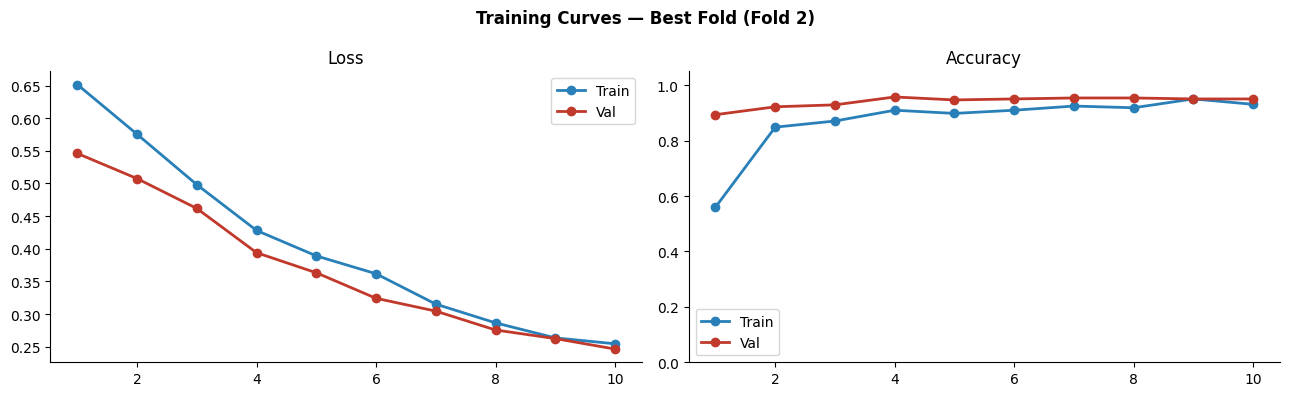

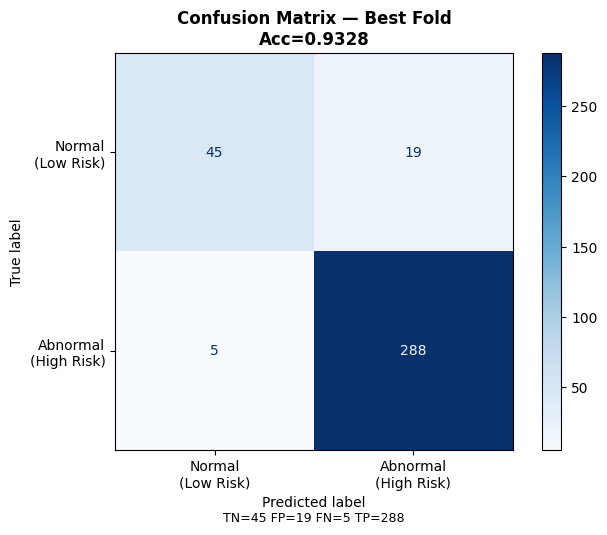

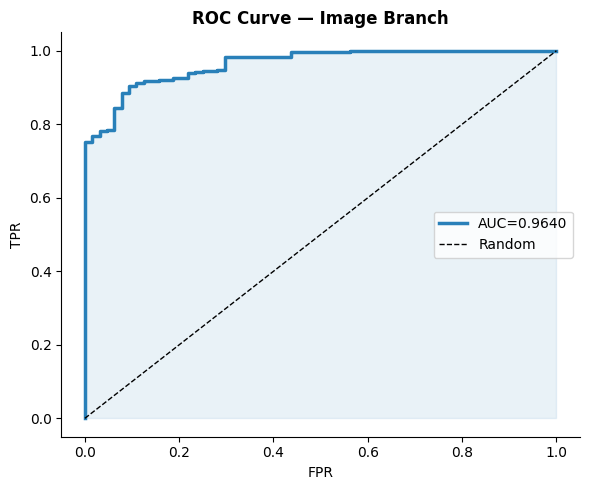

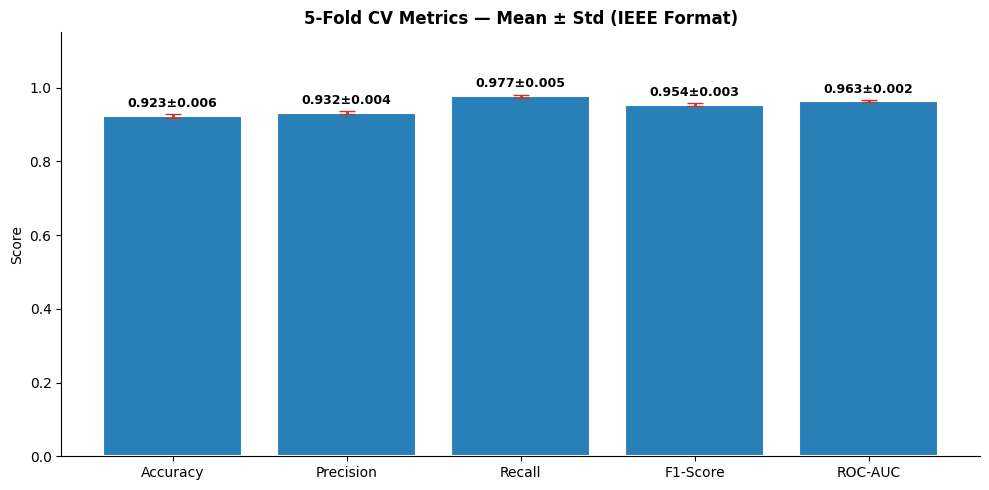

In [28]:
# Training curves — best fold
hist = fold_histories[best_fold_idx]
fig, axes = plt.subplots(1,2,figsize=(13,4))
fig.suptitle(f"Training Curves — Best Fold (Fold {best_fold_idx+1})",
             fontweight="bold")
ep = range(1, len(hist["train_loss"])+1)
axes[0].plot(ep,hist["train_loss"],"o-",color="#2980b9",label="Train",lw=2)
axes[0].plot(ep,hist["val_loss"],  "o-",color="#c0392b",label="Val",  lw=2)
axes[0].set_title("Loss"); axes[0].legend()
axes[0].spines[["top","right"]].set_visible(False)
axes[1].plot(ep,hist["train_acc"],"o-",color="#2980b9",label="Train",lw=2)
axes[1].plot(ep,hist["val_acc"],  "o-",color="#c0392b",label="Val",  lw=2)
axes[1].set_title("Accuracy"); axes[1].set_ylim(0,1.05); axes[1].legend()
axes[1].spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"01_training_curves.png",dpi=150,bbox_inches="tight")
plt.show()

# Confusion matrix
cm = confusion_matrix(labels, preds)
tn,fp,fn,tp = cm.ravel()
fig, ax = plt.subplots(figsize=(7,5.5))
ConfusionMatrixDisplay(cm,
    display_labels=["Normal\n(Low Risk)","Abnormal\n(High Risk)"]).plot(
    ax=ax,colorbar=True,cmap="Blues")
ax.set_title(f"Confusion Matrix — Best Fold\nAcc={accuracy_score(labels,preds):.4f}",
             fontweight="bold")
ax.text(0.5,-0.18,f"TN={tn} FP={fp} FN={fn} TP={tp}",
        ha="center",transform=ax.transAxes,fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"02_confusion_matrix.png",dpi=150,bbox_inches="tight")
plt.show()

# ROC curve
auc = roc_auc_score(labels,probs)
fpr,tpr,_ = roc_curve(labels,probs)
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(fpr,tpr,lw=2.5,color="#2980b9",label=f"AUC={auc:.4f}")
ax.fill_between(fpr,tpr,alpha=0.1,color="#2980b9")
ax.plot([0,1],[0,1],"k--",lw=1,label="Random")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC Curve — Image Branch",fontweight="bold")
ax.legend(); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"03_roc_curve.png",dpi=150,bbox_inches="tight")
plt.show()

# CV metrics bar with error bars
fig, ax = plt.subplots(figsize=(10,5))
metric_names = list(summary.keys())
means = [summary[m][0] for m in metric_names]
stds  = [summary[m][1] for m in metric_names]
bars  = ax.bar(metric_names, means, yerr=stds, capsize=6,
               color="#2980b9", edgecolor="white", linewidth=1.5,
               error_kw={"elinewidth":2,"ecolor":"#c0392b"})
ax.set_ylim(0,1.15); ax.set_ylabel("Score")
ax.set_title("5-Fold CV Metrics — Mean ± Std (IEEE Format)",
             fontweight="bold",fontsize=12)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x()+bar.get_width()/2, m+s+0.02,
            f"{m:.3f}±{s:.3f}", ha="center", fontsize=9, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"04_cv_metrics_with_errorbars.png",dpi=150,bbox_inches="tight")
plt.show()

## 13. Extract Embeddings for Fusion

In [29]:
@torch.no_grad()
def extract_embeddings(model, loader):
    model.eval()
    all_emb, all_lbl = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        emb  = model(imgs, return_embedding=True)
        all_emb.append(emb.cpu().numpy())
        all_lbl.append(labels.numpy())
    return np.vstack(all_emb), np.concatenate(all_lbl)

# Use best fold model for embeddings
train_ds_full = FetalBrainDataset(train_df, is_train=False)
train_ld_full = DataLoader(train_ds_full, BATCH_SIZE, shuffle=False, num_workers=2)

img_train_emb, img_train_lbl = extract_embeddings(best_model, train_ld_full)
img_test_emb,  img_test_lbl  = extract_embeddings(best_model, test_loader)

np.save(OUTPUT_DIR/"img_train_embeddings.npy", img_train_emb)
np.save(OUTPUT_DIR/"img_train_labels.npy",     img_train_lbl)
np.save(OUTPUT_DIR/"img_test_embeddings.npy",  img_test_emb)
np.save(OUTPUT_DIR/"img_test_labels.npy",      img_test_lbl)

print(f"Train embeddings: {img_train_emb.shape}")
print(f"Test  embeddings: {img_test_emb.shape}")
print("Embeddings saved for fusion ✅")

Train embeddings: (1411, 128)
Test  embeddings: (357, 128)
Embeddings saved for fusion ✅


## 14. Final Summary

In [30]:
print("=" * 60)
print("  IMAGE BRANCH RESULTS")
print("=" * 60)
print(f"  Dataset         : Fetal Brain Abnormalities Ultrasound")
print(f"  Model           : ResNet-18 (pretrained ImageNet)")
print(f"  Validation      : {N_FOLDS}-Fold Stratified Cross Validation")
print(f"  Leakage fix     : Split by base image name ✅")
print(f"  Balancing fix   : Heavy augmentation on minority class ✅")
print(f"  Early stopping  : Patience={PATIENCE} ✅")
print(f"  Image size      : {IMG_SIZE}x{IMG_SIZE}")
print()
print(f"  {'Metric':<12} {'Mean':>8} {'±Std':>8}")
print(f"  {'-'*30}")
for metric, (mean, std) in summary.items():
    print(f"  {metric:<12} {mean:>8.4f} {std:>8.4f}")
print("=" * 60)
print(f"\nAll outputs: {OUTPUT_DIR.resolve()}")

  IMAGE BRANCH RESULTS
  Dataset         : Fetal Brain Abnormalities Ultrasound
  Model           : ResNet-18 (pretrained ImageNet)
  Validation      : 5-Fold Stratified Cross Validation
  Leakage fix     : Split by base image name ✅
  Balancing fix   : Heavy augmentation on minority class ✅
  Early stopping  : Patience=3 ✅
  Image size      : 224x224

  Metric           Mean     ±Std
  ------------------------------
  Accuracy       0.9227   0.0058
  Precision      0.9323   0.0041
  Recall         0.9768   0.0045
  F1-Score       0.9540   0.0034
  ROC-AUC        0.9631   0.0022

All outputs: /content/outputs_image_fixed


In [31]:
import shutil

# Zip both output folders
shutil.make_archive("/content/outputs_image_fixed", "zip", "/content/outputs_image_fixed")


print("Zips created ✅")

Zips created ✅


In [32]:
from google.colab import files
files.download("/content/outputs_image_fixed.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>